# Notebook 1: Data Download & Feature Engineering

**FRE-GY 7773 — Group 2**: Zhang Xiaoyang, Zhao Zhiqi, Gupta Prachee

This notebook:
1. Downloads historical OHLCV data from Yahoo Finance
2. Constructs technical indicator features
3. Creates the prediction target (next-day return direction)
4. Splits data into train / test sets
5. Saves the processed dataset for use in notebook 02

## 0. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')

print('All imports successful.')

All imports successful.


## 1. Download Data

In [2]:
TICKER = 'SPY'       # S&P 500 ETF — liquid, well-studied
START  = '2015-01-01'
END    = '2024-12-31'

raw = yf.download(TICKER, start=START, end=END, auto_adjust=True)
raw.columns = raw.columns.get_level_values(0)
raw = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# VIX — fear index, strong directional signal
vix_raw = yf.download('^VIX', start=START, end=END, auto_adjust=True)
vix_raw.columns = vix_raw.columns.get_level_values(0)
vix = vix_raw['Close'].rename('vix')

print(f'SPY: {len(raw)} trading days  ({raw.index[0].date()} → {raw.index[-1].date()})')
print(f'VIX: {len(vix)} trading days  ({vix.index[0].date()} → {vix.index[-1].date()})')
raw.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

SPY: 2515 trading days  (2015-01-02 → 2024-12-30)
VIX: 2515 trading days  (2015-01-02 → 2024-12-30)


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,170.911729,171.325799,169.089809,170.124985,121465900
2015-01-05,169.081586,169.247212,166.746235,167.052643,169632600
2015-01-06,167.358966,167.880699,164.684075,165.479095,209151400
2015-01-07,166.804123,167.880709,166.356933,167.541168,125346700
2015-01-08,168.949035,170.729546,168.932482,170.514221,147217800


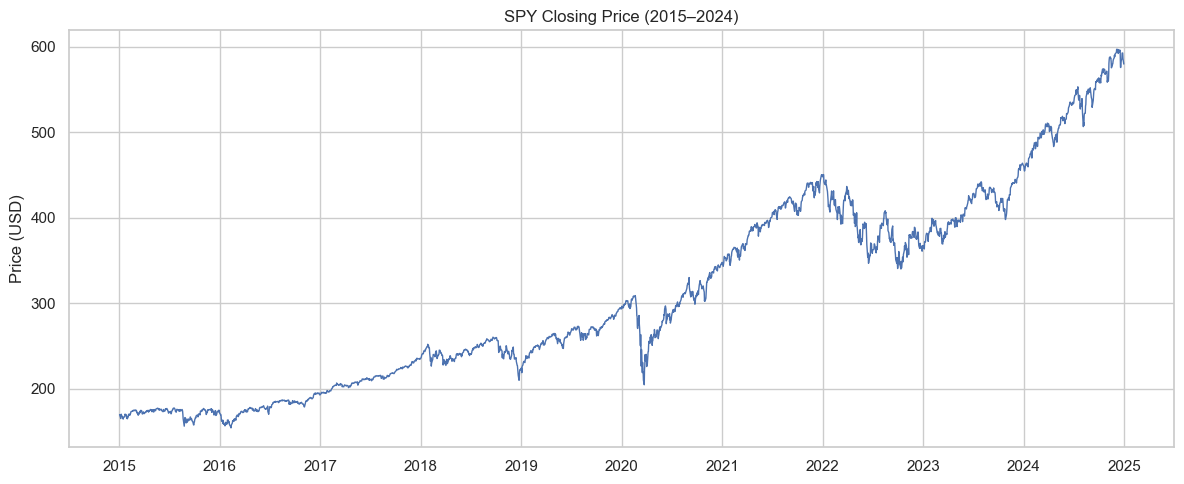

In [3]:
# Quick sanity check — plot closing price
fig, ax = plt.subplots()
ax.plot(raw.index, raw['Close'], linewidth=1)
ax.set_title(f'{TICKER} Closing Price ({START[:4]}–{END[:4]})')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.savefig('../results/01_closing_price.png', dpi=150)
plt.show()

## 2. Feature Engineering

We construct 10 features from OHLCV data and VIX.

| Feature | Formula / Description |
|---|---|
| `ma_ratio` | ma5 / ma20 — short vs long-term trend |
| `momentum5` | Close / Close[t-5] - 1 — 5-day return |
| `momentum20` | Close / Close[t-20] - 1 — 20-day return |
| `rsi14` | Relative Strength Index (14-day) |
| `macd` | EMA12 - EMA26 |
| `macd_signal` | 9-day EMA of MACD |
| `bb_position` | (Close - BB_lower) / (BB_upper - BB_lower) |
| `volume_zscore` | (Volume - 20d mean) / 20d std — normalized volume |
| `overnight_gap` | Open[t] / Close[t-1] - 1 — gap at open |
| `vix` | CBOE VIX index level — market fear gauge |

In [4]:
def compute_rsi(series: pd.Series, window: int = 14) -> pd.Series:
    """Wilder's RSI."""
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/window, min_periods=window, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    close = d['Close']

    # Moving averages
    d['ma5']      = close.rolling(5).mean()
    d['ma20']     = close.rolling(20).mean()
    d['ma_ratio'] = d['ma5'] / d['ma20']

    # Momentum
    d['momentum5']  = close.pct_change(5)
    d['momentum20'] = close.pct_change(20)

    # RSI
    d['rsi14'] = compute_rsi(close, 14)

    # MACD
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    d['macd']        = ema12 - ema26
    d['macd_signal'] = d['macd'].ewm(span=9, adjust=False).mean()

    # Bollinger Bands (20-day, 2 std)
    bb_mid   = close.rolling(20).mean()
    bb_std   = close.rolling(20).std()
    bb_upper = bb_mid + 2 * bb_std
    bb_lower = bb_mid - 2 * bb_std
    d['bb_position'] = (close - bb_lower) / (bb_upper - bb_lower)

    # Volume z-score (normalized vs raw pct_change — more robust)
    vol_mean = d['Volume'].rolling(20).mean()
    vol_std  = d['Volume'].rolling(20).std()
    d['volume_zscore'] = (d['Volume'] - vol_mean) / vol_std

    # Overnight gap: open vs previous close — informs gap direction at open
    d['overnight_gap'] = d['Open'] / d['Close'].shift(1) - 1

    return d


df = build_features(raw)

# Merge VIX — forward-fill any holiday gaps, no look-ahead since it's same-day close
df = df.join(vix, how='left')
df['vix'] = df['vix'].ffill()

print(f'Dataframe shape after feature engineering: {df.shape}')
df[['Close', 'volume_zscore', 'overnight_gap', 'vix']].tail(3)

Dataframe shape after feature engineering: (2515, 17)


,Close,volume_zscore,overnight_gap,vix
Date,,,,
2024-12-26,592.741577,-0.218348,-0.002993,14.73
2024-12-27,586.502014,0.583032,-0.006319,15.95
2024-12-30,579.809143,0.235425,-0.011966,17.40


## 3. Build Target Variable

We predict **next-day return direction**: 1 = up, 0 = down (or flat).

In [5]:
# next-day return
df['next_return'] = df['Close'].pct_change().shift(-1)

# binary label: 1 if market goes up, 0 otherwise
df['target'] = (df['next_return'] > 0).astype(int)

# Drop rows with NaN (from rolling windows and the last row with no future return)
df.dropna(inplace=True)

print(f'Dataset size after cleaning: {len(df)} rows')
print(f"\nClass balance:\n{df['target'].value_counts()}")
print(f"\nUp days: {df['target'].mean()*100:.1f}%")

Dataset size after cleaning: 2494 rows

Class balance:
target
1    1364
0    1130
Name: count, dtype: int64

Up days: 54.7%


## 4. Train / Test Split

We use a **time-based split** — never random, to avoid look-ahead bias.

- **Train**: 2015–2022
- **Test**:  2023–2024

In [6]:
FEATURE_COLS = [
    'ma_ratio', 'momentum5', 'momentum20',
    'rsi14', 'macd', 'macd_signal',
    'bb_position', 'volume_zscore',
    'overnight_gap', 'vix'
]

SPLIT_DATE = '2023-01-01'

train = df[df.index < SPLIT_DATE]
test  = df[df.index >= SPLIT_DATE]

X_train = train[FEATURE_COLS]
y_train = train['target']
X_test  = test[FEATURE_COLS]
y_test  = test['target']

print(f'Train: {len(train)} days  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test:  {len(test)} days   ({test.index[0].date()} → {test.index[-1].date()})')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Train: 1994 days  (2015-02-02 → 2022-12-30)
Test:  500 days   (2023-01-03 → 2024-12-27)
Features (10): ['ma_ratio', 'momentum5', 'momentum20', 'rsi14', 'macd', 'macd_signal', 'bb_position', 'volume_zscore', 'overnight_gap', 'vix']


## 5. Exploratory Analysis

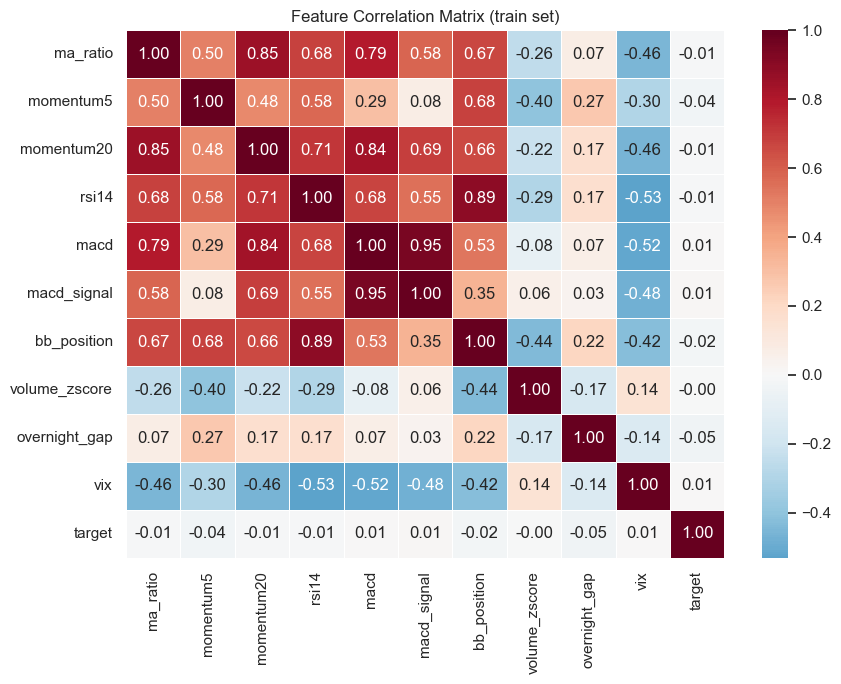

In [7]:
# Correlation heatmap of features
fig, ax = plt.subplots(figsize=(9, 7))
corr = train[FEATURE_COLS + ['target']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix (train set)')
plt.tight_layout()
plt.savefig('../results/01_correlation_heatmap.png', dpi=150)
plt.show()

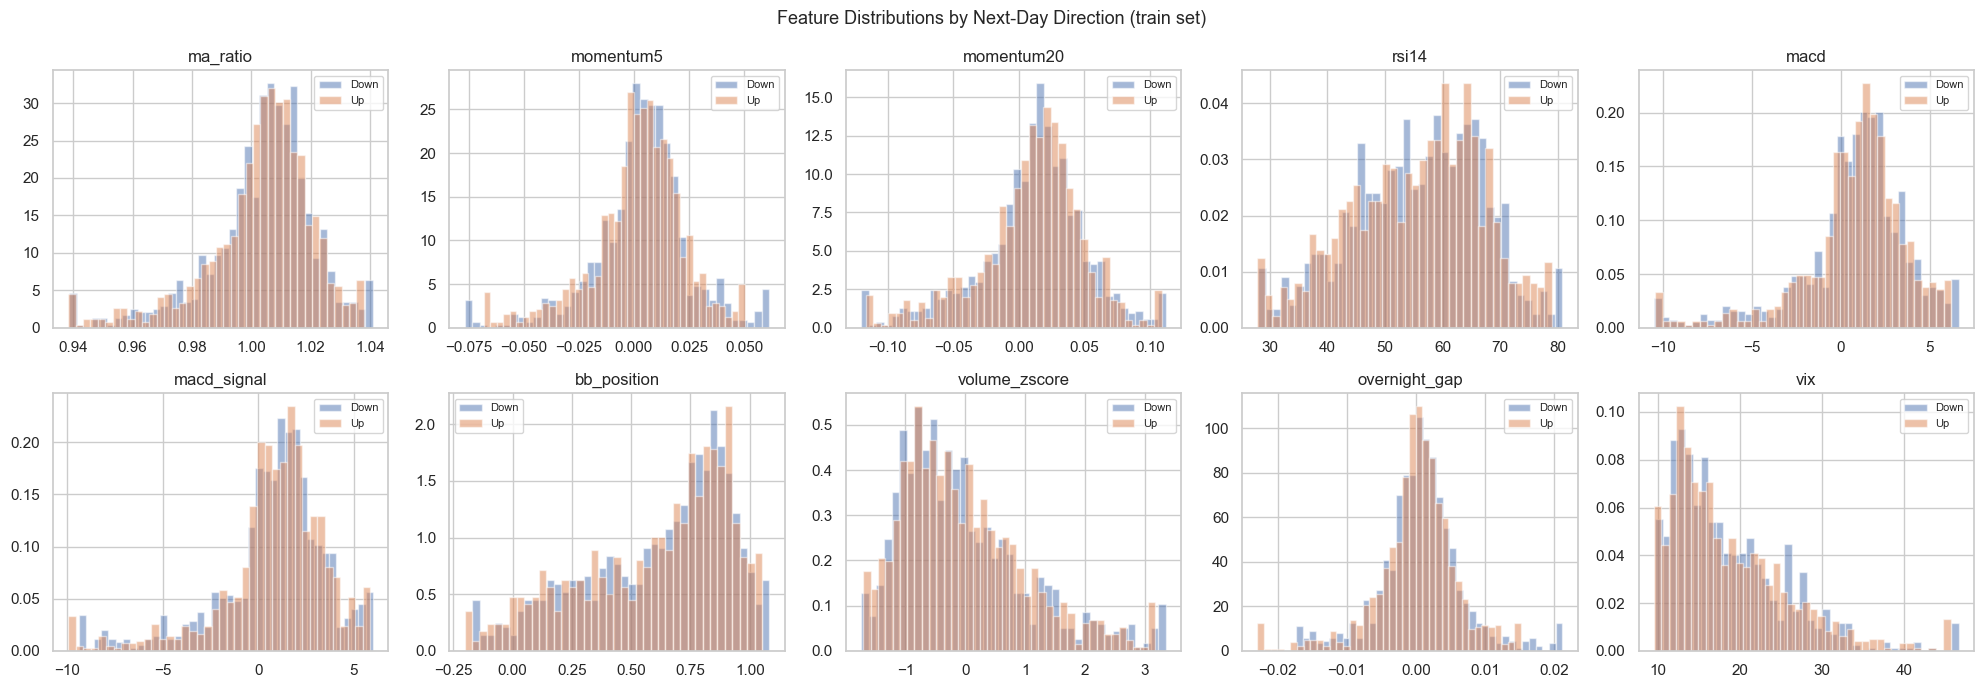

In [8]:
n_cols = 5
n_rows = (len(FEATURE_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 7))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    for label, grp in train.groupby('target'):
        axes[i].hist(grp[col].clip(
            grp[col].quantile(0.01), grp[col].quantile(0.99)),
            bins=40, alpha=0.5,
            label='Up' if label == 1 else 'Down', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

# hide unused subplots
for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions by Next-Day Direction (train set)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/01_feature_distributions.png', dpi=150)
plt.show()

## 6. Save Processed Data

In [9]:
# Save train and test sets
train.to_csv('../data/train.csv')
test.to_csv('../data/test.csv')

# Also save feature/target names for use in later notebooks
import json as _json
with open('../data/config.json', 'w') as f:
    _json.dump({'feature_cols': FEATURE_COLS, 'target_col': 'target'}, f, indent=2)

print('Saved:')
print('  data/train.csv')
print('  data/test.csv')
print('  data/config.json')

Saved:
  data/train.csv
  data/test.csv
  data/config.json


---
**Next**: Open `02_modeling.ipynb` to train and evaluate the models.